In [1]:
import sys
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.serialize import model_to_json, model_from_json
import json
from src.mypackage.data_preparation import prepare_prophet_data
from src.mypackage.evaluation import print_metrics
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED

set_seed(SEED)

In [2]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
train, test = prepare_prophet_data(df)

In [3]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
m.add_country_holidays(country_name="US")
m.add_regressor("is_weekend")
m.fit(train)

with open("../models/prophet_best_model.json", "w") as f:
    json.dump(model_to_json(m), f)

18:06:01 - cmdstanpy - INFO - Chain [1] start processing
18:09:09 - cmdstanpy - INFO - Chain [1] done processing


In [3]:
with open("../models/prophet_best_model.json", "r") as f:
    model_json = json.load(f)
m = model_from_json(model_json)

In [4]:
# 1年先を予測
future = m.make_future_dataframe(periods=len(test), freq='h')
future["is_weekend"] = future["ds"].dt.weekday >= 5
future.tail()

,ds,is_weekend
145358,2018-08-02 20:00:00,False
145359,2018-08-02 21:00:00,False
145360,2018-08-02 22:00:00,False
145361,2018-08-02 23:00:00,False
145362,2018-08-03 00:00:00,False


In [5]:
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
145358,2018-08-02 20:00:00,31064.392873,36177.469570,48473.607308,27154.753640,34947.049674,0.0,0.0,0.0,0.0,...,593.810952,593.810952,593.810952,5901.096246,5901.096246,5901.096246,0.0,0.0,0.0,41993.449000
145359,2018-08-02 21:00:00,31064.369600,35173.603509,47755.066939,27153.995765,34947.620848,0.0,0.0,0.0,0.0,...,580.057764,580.057764,580.057764,5896.324439,5896.324439,5896.324439,0.0,0.0,0.0,41205.412542
145360,2018-08-02 22:00:00,31064.346326,33105.914580,46163.770347,27153.237890,34948.192021,0.0,0.0,0.0,0.0,...,566.929269,566.929269,566.929269,5891.552776,5891.552776,5891.552776,0.0,0.0,0.0,39578.675101
145361,2018-08-02 23:00:00,31064.323052,30966.248147,43784.826941,27152.480015,34948.763194,0.0,0.0,0.0,0.0,...,554.402924,554.402924,554.402924,5886.781352,5886.781352,5886.781352,0.0,0.0,0.0,37394.591312
145362,2018-08-03 00:00:00,31064.299779,29172.499907,41018.081791,27151.722140,34949.334367,0.0,0.0,0.0,0.0,...,542.428030,542.428030,542.428030,5882.010260,5882.010260,5882.010260,0.0,0.0,0.0,35105.298678


In [7]:
print_metrics(test["y"], forecast["yhat"][-len(test):], "Prophet Forecast (1 Year)")

Prophet Forecast (1 Year):
MAE: 3230.34
RMSE: 4206.20
MAPE: 10.20%



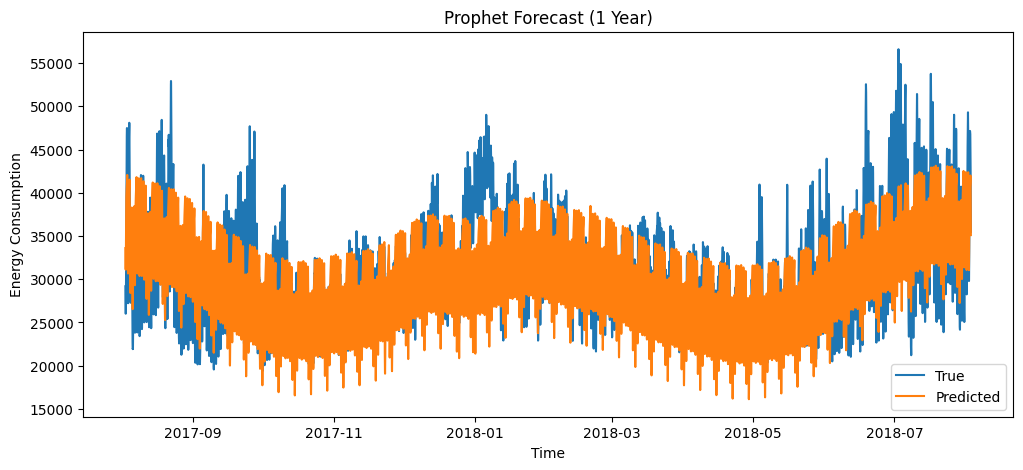

In [8]:
plot_forecast(test["y"].values, forecast["yhat"][-len(test):], test["ds"], "Prophet Forecast (1 Year)")

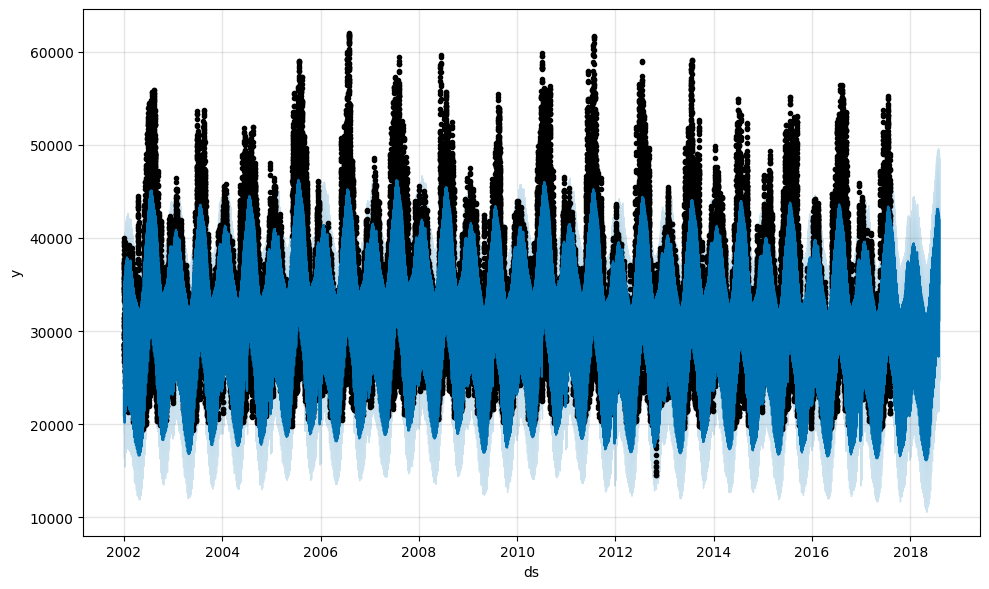

In [9]:
fig1 = m.plot(forecast)

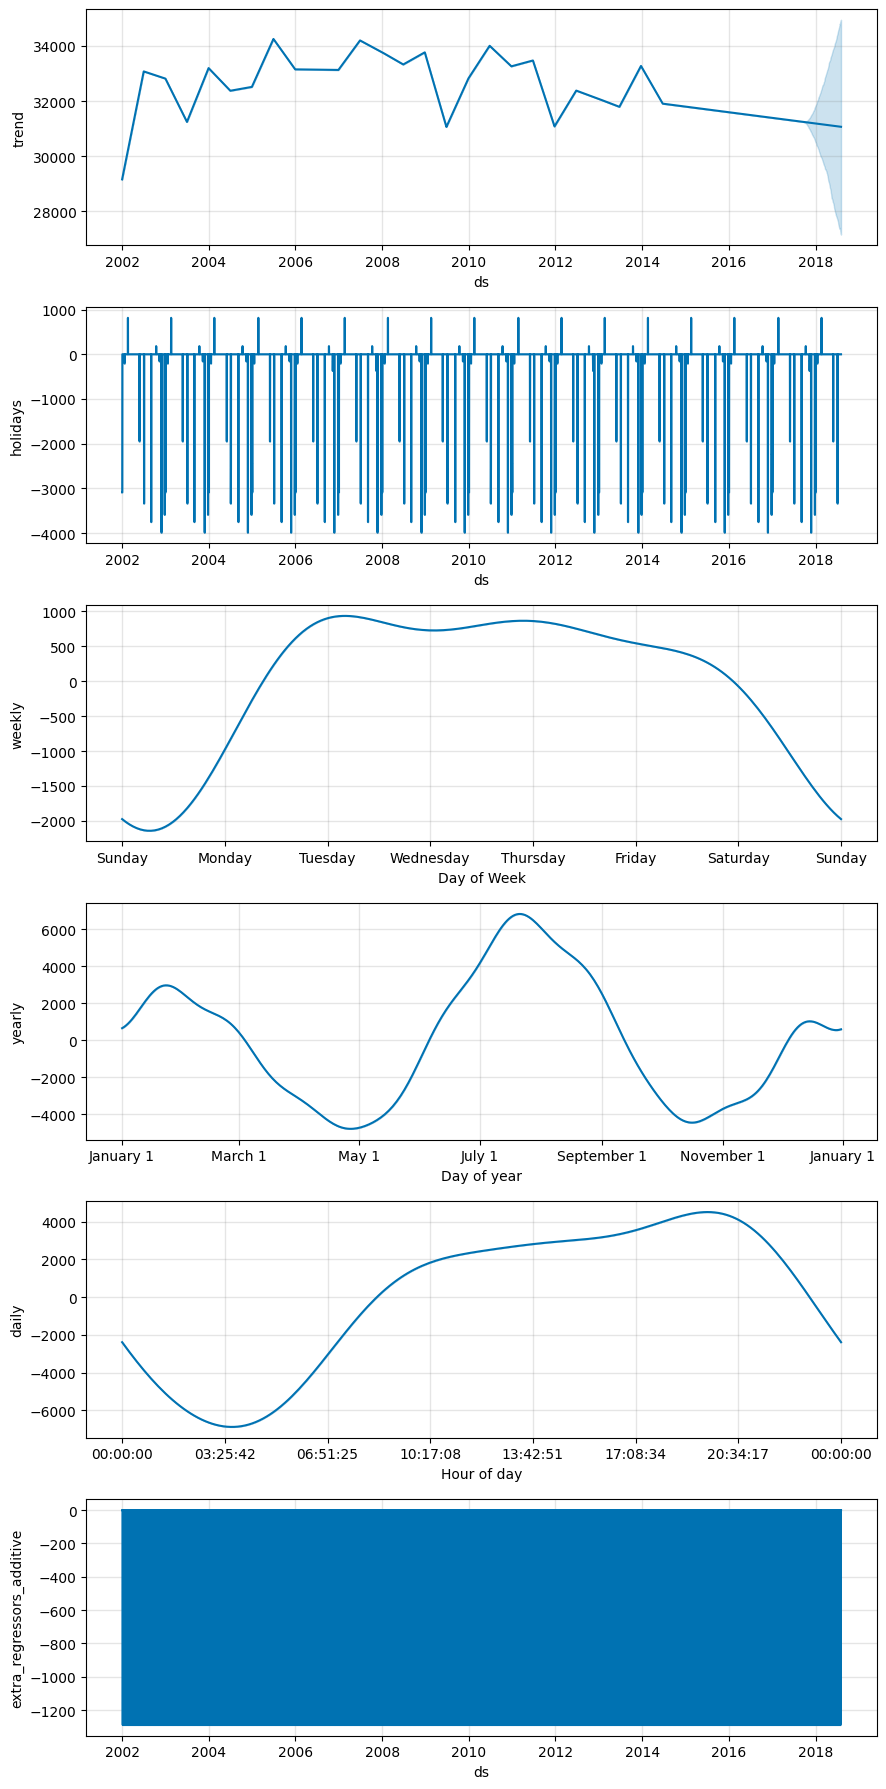

In [10]:
fig2 = m.plot_components(forecast)